# Training history visualization

Loads `config.json`, `history.json` and `history_val.json` from a run folder under `trained_models/<timestamp>/` (see `main.py`) and plots train vs. validation curves.

**Note on the x-axis:** each history key is only appended on the epochs where it was actually computed (e.g. `mse_phi` during the phi-stage epochs, `res_1..res_3` only for the occasional full-residual batches before `PHI_EPOCHS`, `res_4`/`res_sum` on every flow epoch). The lists are therefore not all the same length and the x-axis below is the **index within that series** (the n-th time the metric was logged), not the raw epoch number.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np

# --- validated categorical palette (dataviz skill), fixed order, never cycled ---
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

METRIC_COLORS = {
    'res_1':   '#2a78d6',  # blue
    'res_2':   '#1baf7a',  # aqua
    'res_3':   '#eda100',  # yellow
    'res_4':   '#008300',  # green
    'res_sum': '#4a3aa7',  # violet
    'mse_phi': '#e34948',  # red
    'lr_flow': '#e87ba4',  # magenta
    'lr_phi':  '#eb6834',  # orange
}

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRIDLINE,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.6,
    'font.size': 11,
})

## Pick a run

Leave `RUN_DIR = None` to auto-pick the most recent folder under `trained_models/` (names sort chronologically since they are `%Y-%m-%d_%H-%M-%S`).

In [2]:
TRAINED_MODELS_DIR = 'trained_models'
RUN_DIR = None  # e.g. 'trained_models/2026-07-04_12-00-00' to pin a specific run

if RUN_DIR is None:
    if not os.path.isdir(TRAINED_MODELS_DIR):
        raise FileNotFoundError(
            f"'{TRAINED_MODELS_DIR}/' does not exist. Run main.py first, or set RUN_DIR explicitly."
        )
    runs = sorted(
        d for d in os.listdir(TRAINED_MODELS_DIR)
        if os.path.isdir(os.path.join(TRAINED_MODELS_DIR, d))
    )
    if not runs:
        raise FileNotFoundError(
            f"No run folders found under '{TRAINED_MODELS_DIR}/'. Run main.py first, "
            "or set RUN_DIR explicitly."
        )
    RUN_DIR = os.path.join(TRAINED_MODELS_DIR, runs[-1])

print(f'Using run: {RUN_DIR}')

Using run: trained_models\2026-07-05_15-03-17


In [3]:
def load_json(path, default=None):
    if not os.path.exists(path):
        print(f'(missing: {path})')
        return default
    with open(path, 'r') as fp:
        return json.load(fp)

config = load_json(os.path.join(RUN_DIR, 'config.json'), default={})
history = load_json(os.path.join(RUN_DIR, 'history.json'), default={})
history_val = load_json(os.path.join(RUN_DIR, 'history_val.json'), default={})

RES_KEYS = ['res_1', 'res_2', 'res_3', 'res_4', 'res_sum']
LR_KEYS = ['lr_flow', 'lr_phi']

## Run config

In [4]:
if config:
    width = max((len(k) for k in config), default=0)
    for k, v in config.items():
        print(f'{k:<{width}}  {v}')
else:
    print('No config.json found for this run.')

LOCAL          True
FULL_TRAIN     False
USE_CLEARML    False
USE_EMB        True
ACT            wave
INTERIOR_SIZE  500
WALLS_SIZE     250
INLET_SIZE     100
OUTLET_SIZE    100
OUTERIOR_SIZE  250
Q              1.5e-06
S              2e-06
PHI_EPOCHS     10000
EPOCHS         200
DIV_POR        5
VAL_EVERY      50
B              2
RESUME_PINN    False
RESUME_TASK    a6c0b9d0b4b44b918462644b3c35e3af
GEN_POINTS     False
DATASET_PATH   SimVascDataset
SPLIT          {'train': ['0145_H_CORO_KD', '0151_H_AO_H'], 'val': ['0096_A_AO_COA'], 'test': ['0209_H_CERE_CA']}


## Plot helpers

In [5]:
def plot_metric(ax, key, log_scale=True):
    color = METRIC_COLORS.get(key, INK_SECONDARY)
    train_vals = history.get(key, [])
    val_vals = history_val.get(key, [])

    has_data = False
    if train_vals:
        ax.plot(np.arange(len(train_vals)), train_vals, color=color, linestyle='-',
                label=f'{key} (train)')
        has_data = True
    if val_vals:
        ax.plot(np.arange(len(val_vals)), val_vals, color=color, linestyle='--',
                marker='o', markersize=3, label=f'{key} (val)')
        has_data = True

    ax.set_title(key, color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('logged index')

    if not has_data:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center',
                color=INK_MUTED)
        return

    if log_scale and all(v > 0 for v in train_vals + val_vals):
        ax.set_yscale('log')
    ax.legend(frameon=False, fontsize=9)


def plot_group(keys, log_scale=True, suptitle=None):
    n = len(keys)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
    for idx, key in enumerate(keys):
        plot_metric(axes[idx // ncols][idx % ncols], key, log_scale=log_scale)
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')
    if suptitle:
        fig.suptitle(suptitle, color=INK_PRIMARY, fontsize=13)
    fig.tight_layout()
    return fig

## Phi-stage loss

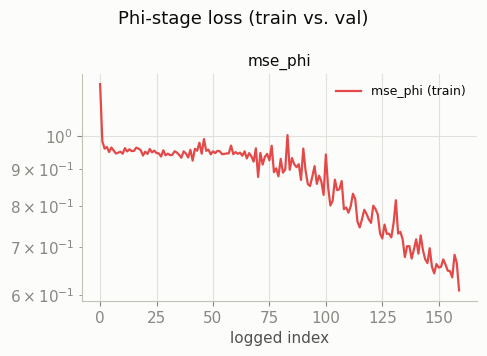

In [6]:
plot_group(['mse_phi'], log_scale=True, suptitle='Phi-stage loss (train vs. val)')
plt.show()

## Flow-stage residuals

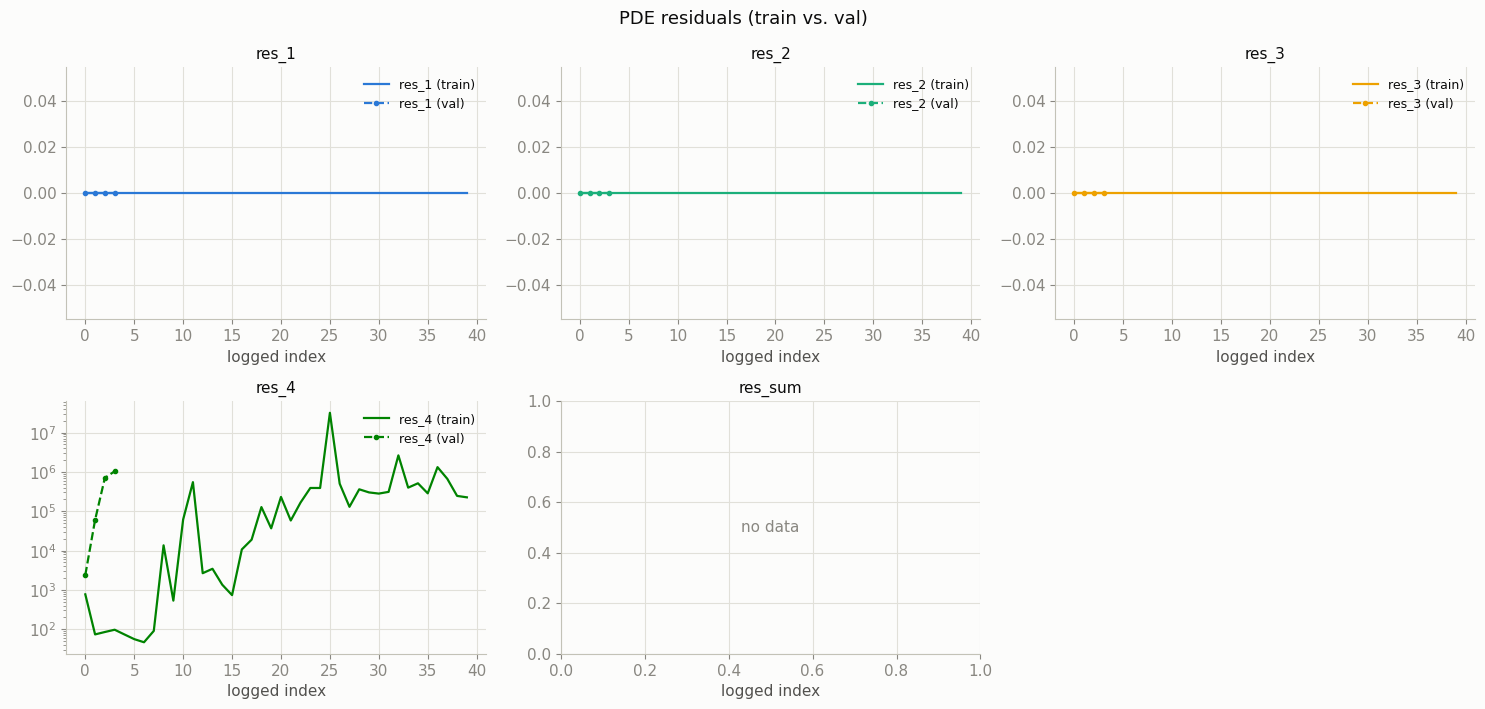

In [7]:
plot_group(RES_KEYS, log_scale=True, suptitle='PDE residuals (train vs. val)')
plt.show()

## Learning rates

Train-only (no LR schedule is stepped during validation). Kept on separate axes rather than a dual-axis plot since `lr_flow` and `lr_phi` follow independent schedules.

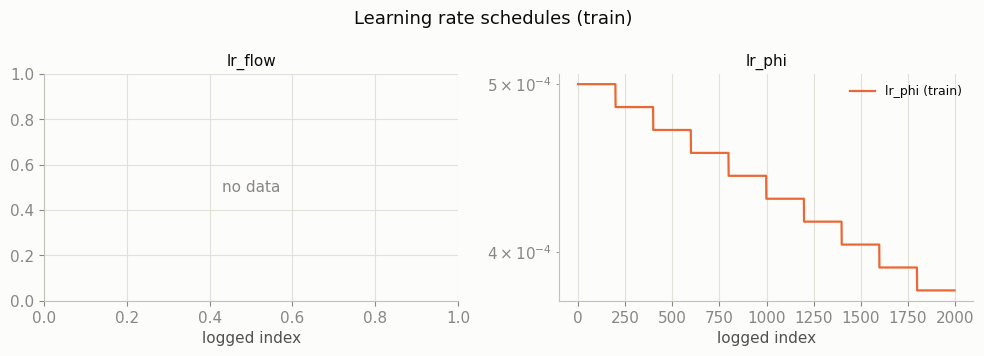

In [8]:
plot_group(LR_KEYS, log_scale=True, suptitle='Learning rate schedules (train)')
plt.show()

## Summary: last & best values

In [9]:
def summarize(key):
    row = {'metric': key}
    for split_name, split_hist in [('train', history), ('val', history_val)]:
        vals = split_hist.get(key, [])
        if vals:
            best_idx = int(np.argmin(vals))
            row[f'{split_name}_last'] = vals[-1]
            row[f'{split_name}_best'] = vals[best_idx]
            row[f'{split_name}_best_idx'] = best_idx
        else:
            row[f'{split_name}_last'] = None
            row[f'{split_name}_best'] = None
            row[f'{split_name}_best_idx'] = None
    return row

rows = [summarize(k) for k in RES_KEYS + ['mse_phi']]

header = ['metric', 'train_last', 'train_best', 'train_best_idx', 'val_last', 'val_best', 'val_best_idx']
col_w = {h: max(len(h), *(len(str(r[h])) for r in rows)) for h in header}
print('  '.join(h.ljust(col_w[h]) for h in header))
for r in rows:
    print('  '.join(str(r[h]).ljust(col_w[h]) for h in header))

metric   train_last            train_best            train_best_idx  val_last           val_best            val_best_idx
res_1    None                  None                  None            None               None                None        
res_2    None                  None                  None            None               None                None        
res_3    None                  None                  None            None               None                None        
res_4    None                  None                  None            None               None                None        
res_sum  None                  None                  None            None               None                None        
mse_phi  0.026031188666820526  0.021928881228502308  1986            0.539901202917099  0.1983821839094162  10          
